# Wine Classification System using k-NN and PCA

## Business Context
A premium wine distributor needs an automated classification system to identify wine varieties from chemical properties. This notebook develops a supervised machine learning prototype using **k-Nearest Neighbors (k-NN)** combined with **Principal Component Analysis (PCA)** and systematic hyperparameter tuning.

## Modelling Goal
Predict the wine class in the `Wine` column using the chemical measurement columns as input features.

## Data Source
This notebook uses `wine.csv`, which contains 178 wine records, 13 chemical input features, and the target column `Wine`.

## Step 1: Import Libraries
This step loads the core libraries required for data handling, modelling, PCA, hyperparameter tuning, and model evaluation.

In [20]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Step 2: Load the Wine Dataset
The notebook expects `wine.csv` to be in the same folder as the notebook. If it is running in this environment, it also checks `/mnt/data/wine.csv`.

In [21]:
data_path = "wine.csv"
if not os.path.exists(data_path):
    data_path = "/mnt/data/wine.csv"

df = pd.read_csv(data_path)
print("Dataset loaded successfully")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully
Shape: (178, 14)


,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


## Step 3: Test 1 - Data Structure and Target Variable
This test confirms the column structure, separates the target variable, and checks that the dataset contains the expected wine classes.

**Expected result from the attached dataset:**
- Dataset shape: `(178, 14)`
- Target classes: `{1: 59, 2: 71, 3: 48}`
- Feature columns: 13 chemical measurement variables

In [22]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nTarget class counts:")
print(df["Wine"].value_counts().sort_index())

# Features and target
X = df.drop(columns=["Wine"])
y = df["Wine"]

print("\nFeature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Columns:
['Wine', 'Alcohol', 'Malic.acid', 'Ash', 'Acl', 'Mg', 'Phenols', 'Flavanoids', 'Nonflavanoid.phenols', 'Proanth', 'Color.int', 'Hue', 'OD', 'Proline']

Data types:
Wine                      int64
Alcohol                 float64
Malic.acid              float64
Ash                     float64
Acl                     float64
Mg                        int64
Phenols                 float64
Flavanoids              float64
Nonflavanoid.phenols    float64
Proanth                 float64
Color.int               float64
Hue                     float64
OD                      float64
Proline                   int64
dtype: object

Target class counts:
Wine
1    59
2    71
3    48
Name: count, dtype: int64

Feature matrix shape: (178, 13)
Target vector shape: (178,)


## Step 4: Test 2 - Data Quality Checks
This test checks for missing values and duplicate records before modelling.

**Expected result from the attached dataset:**
- Missing values: `0`
- Duplicate rows: `0`

In [23]:
missing_values = df.isna().sum()
duplicate_rows = df.duplicated().sum()

print("Missing values by column:")
print(missing_values)

print()
print("Duplicate rows:", duplicate_rows)

Missing values by column:
Wine                    0
Alcohol                 0
Malic.acid              0
Ash                     0
Acl                     0
Mg                      0
Phenols                 0
Flavanoids              0
Nonflavanoid.phenols    0
Proanth                 0
Color.int               0
Hue                     0
OD                      0
Proline                 0
dtype: int64

Duplicate rows: 0


## Step 5: Exploratory Check - Class Distribution
This chart confirms whether the target classes are reasonably represented before model training.

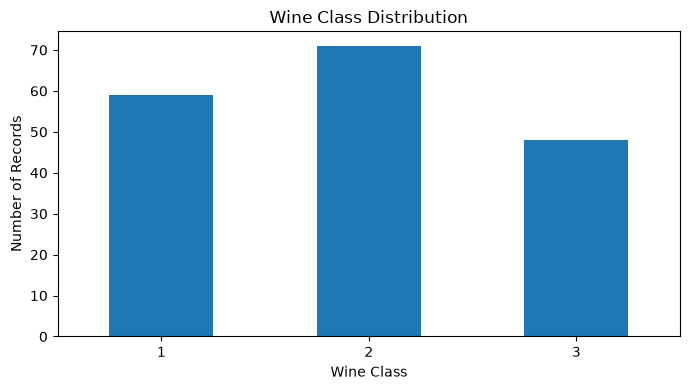

In [24]:
class_counts = y.value_counts().sort_index()
ax = class_counts.plot(kind="bar", figsize=(7, 4))
ax.set_title("Wine Class Distribution")
ax.set_xlabel("Wine Class")
ax.set_ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Step 6: Train-Test Split
A stratified train-test split is used to preserve the class distribution in both training and testing datasets.

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set:", X_train.shape, y_train.shape)
print("Testing set:", X_test.shape, y_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True).sort_index())

Training set: (133, 13) (133,)
Testing set: (45, 13) (45,)

Training class distribution:
Wine
1    0.330827
2    0.398496
3    0.270677
Name: proportion, dtype: float64

Testing class distribution:
Wine
1    0.333333
2    0.400000
3    0.266667
Name: proportion, dtype: float64


## Step 7: Test 3 - Baseline k-NN Model Without PCA
This establishes a baseline using standardized features and k-NN. The baseline helps assess whether PCA and tuning improve or preserve performance.

**Expected result from the attached dataset:**
- Baseline k-NN test accuracy: `0.9333`

In [26]:
baseline_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

baseline_pipeline.fit(X_train, y_train)

y_pred_baseline = baseline_pipeline.predict(X_test)
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)

print(f"Baseline k-NN test accuracy: {baseline_accuracy:.4f}")

print("\nBaseline Classification Report:")
print(classification_report(y_test, y_pred_baseline))

Baseline k-NN test accuracy: 0.9333

Baseline Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        15
           2       0.94      0.89      0.91        18
           3       0.85      0.92      0.88        12

    accuracy                           0.93        45
   macro avg       0.93      0.94      0.93        45
weighted avg       0.94      0.93      0.93        45



## Step 8: Test 4 - PCA Explained Variance Analysis
PCA reduces dimensionality while retaining most of the information in the standardized features. This test shows how much variance is explained as components are added.

**Expected result from the attached dataset:**
- PCA components required to explain at least 95% variance: `10`

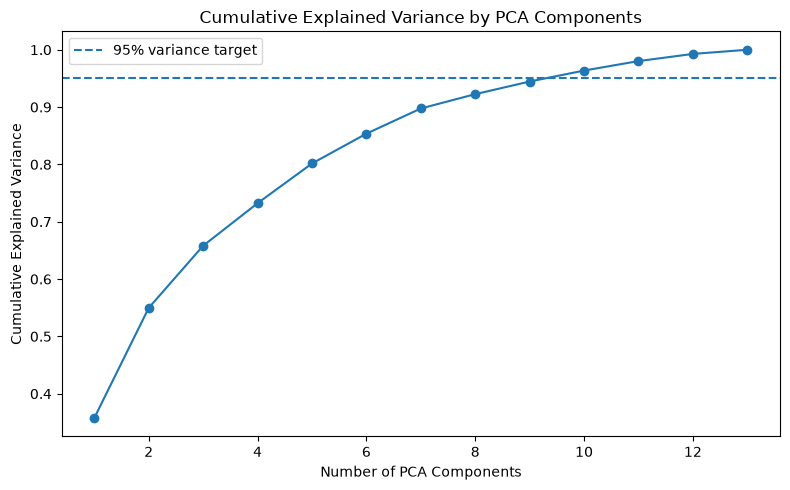

Number of PCA components required to explain at least 95% variance: 10


In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)

explained_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker="o")
plt.axhline(y=0.95, linestyle="--", label="95% variance target")
plt.title("Cumulative Explained Variance by PCA Components")
plt.xlabel("Number of PCA Components")
plt.ylabel("Cumulative Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

components_for_95 = np.argmax(explained_variance >= 0.95) + 1
print(f"Number of PCA components required to explain at least 95% variance: {components_for_95}")

## Step 9: Test 5 - Hyperparameter Tuning for PCA + k-NN
This step uses cross-validation to tune both PCA and k-NN parameters. The selected model balances dimensionality reduction with classification accuracy.

**Expected result from the attached dataset:**
- Best cross-validation accuracy: `0.9852`
- Best parameters: `n_neighbors=1`, `weights='uniform'`, `metric='euclidean'`, `pca__n_components=2`

In [28]:
model_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("pca", PCA(random_state=RANDOM_STATE)),
    ("knn", KNeighborsClassifier())
])

param_grid = {
    "pca__n_components": [2, 3, 4, 5, 6, 7, 8, 9, 10, 0.90, 0.95],
    "knn__n_neighbors": list(range(1, 16)),
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print("Best cross-validation accuracy:", round(grid_search.best_score_, 4))
print("Best parameters:")
print(grid_search.best_params_)

Best cross-validation accuracy: 0.9852
Best parameters:
{'knn__metric': 'euclidean', 'knn__n_neighbors': 1, 'knn__weights': 'uniform', 'pca__n_components': 2}


## Step 10: Test 6 - Final Tuned Model Evaluation
The optimized PCA + k-NN model is evaluated on the holdout test set using accuracy, classification report, and a confusion matrix.

**Expected result from the attached dataset:**
- Final tuned PCA + k-NN test accuracy: `0.8889`
- Confusion matrix:

```text
[[13  2  0]
 [ 1 17  0]
 [ 0  2 10]]
```

Final tuned PCA + k-NN test accuracy: 0.8889

Final Classification Report:
              precision    recall  f1-score   support

           1       0.93      0.87      0.90        15
           2       0.81      0.94      0.87        18
           3       1.00      0.83      0.91        12

    accuracy                           0.89        45
   macro avg       0.91      0.88      0.89        45
weighted avg       0.90      0.89      0.89        45



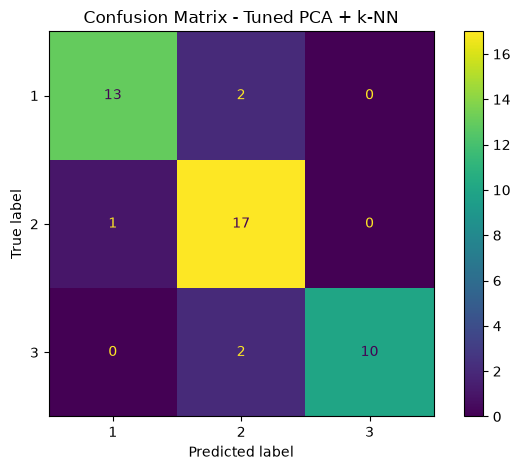

In [29]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
final_accuracy = accuracy_score(y_test, y_pred)

print(f"Final tuned PCA + k-NN test accuracy: {final_accuracy:.4f}")

print("\nFinal Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_model.classes_
)

disp.plot(values_format="d")
plt.title("Confusion Matrix - Tuned PCA + k-NN")
plt.tight_layout()
plt.show()


## Step 11: Test 7 - Cross-Validation Stability of Final Model
This test checks how consistently the final model performs across different folds of the training data.

**Expected result from the attached dataset:**
- Cross-validation scores: `[0.9259, 1.0000, 1.0000, 1.0000, 1.0000]`
- Mean CV accuracy: `0.9852`
- CV accuracy standard deviation: `0.0296`

In [30]:
cv_scores = cross_val_score(best_model, X_train, y_train, cv=cv, scoring="accuracy")
print("Cross-validation scores:", np.round(cv_scores, 4))
print(f"Mean CV accuracy: {cv_scores.mean():.4f}")
print(f"CV accuracy standard deviation: {cv_scores.std():.4f}")

Cross-validation scores: [0.9259 1.     1.     1.     1.    ]
Mean CV accuracy: 0.9852
CV accuracy standard deviation: 0.0296


## Step 12: PCA Visualization in Two Dimensions
This visual check projects the standardized input features into two principal components to show how separable the wine classes are in reduced-dimensional space.

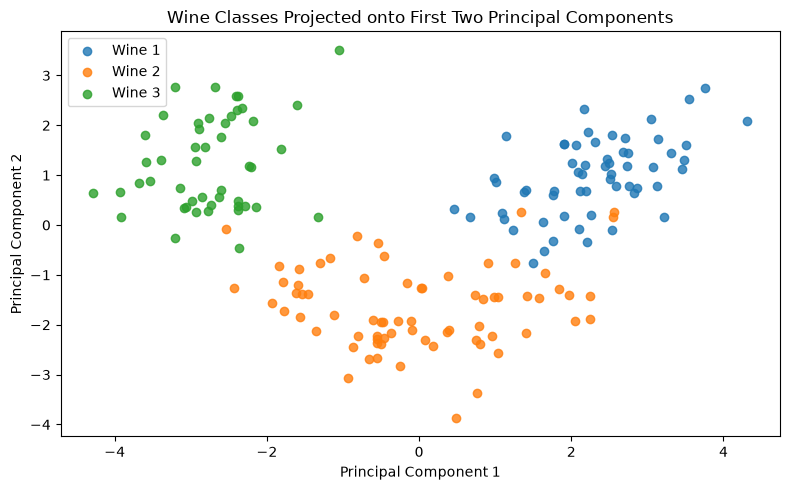

In [31]:
visual_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2, random_state=RANDOM_STATE))
])

X_pca_2d = visual_pipeline.fit_transform(X)
plot_df = pd.DataFrame(X_pca_2d, columns=["PC1", "PC2"])
plot_df["Wine"] = y.values

plt.figure(figsize=(8, 5))
for wine_class in sorted(plot_df["Wine"].unique()):
    subset = plot_df[plot_df["Wine"] == wine_class]
    plt.scatter(subset["PC1"], subset["PC2"], label=f"Wine {wine_class}", alpha=0.8)

plt.title("Wine Classes Projected onto First Two Principal Components")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.show()

## Step 13: Model Results Summary
This step summarizes the most important model outputs for business interpretation.

In [32]:
summary = pd.DataFrame({
    "Metric": [
        "Baseline k-NN Test Accuracy",
        "Best CV Accuracy During Tuning",
        "Final Tuned PCA + k-NN Test Accuracy",
        "Selected PCA Components",
        "Selected k",
        "Selected Distance Metric",
        "Selected Weighting Strategy"
    ],
    "Value": [
        round(baseline_accuracy, 4),
        round(grid_search.best_score_, 4),
        round(final_accuracy, 4),
        grid_search.best_params_["pca__n_components"],
        grid_search.best_params_["knn__n_neighbors"],
        grid_search.best_params_["knn__metric"],
        grid_search.best_params_["knn__weights"]
    ]
})
summary

,Metric,Value
0,Baseline k-NN Test Accuracy,0.9333
1,Best CV Accuracy During Tuning,0.9852
2,Final Tuned PCA + k-NN Test Accuracy,0.8889
3,Selected PCA Components,2
4,Selected k,1
5,Selected Distance Metric,euclidean
6,Selected Weighting Strategy,uniform


## Step 14: Prototype Prediction Function
This function demonstrates how the trained prototype can classify a new wine record using the same preprocessing, PCA transformation, and k-NN classifier.

In [33]:
def predict_wine_class(new_record):
    """
    Predict wine class for one new record.
    new_record should be a dictionary or DataFrame containing the same feature columns used during training.
    """
    if isinstance(new_record, dict):
        new_record = pd.DataFrame([new_record])
    return best_model.predict(new_record)[0]

sample_record = X_test.iloc[0].to_dict()
predicted_class = predict_wine_class(sample_record)
actual_class = y_test.iloc[0]

print("Sample prediction demonstration")
print("Predicted class:", predicted_class)
print("Actual class:", actual_class)

Sample prediction demonstration
Predicted class: 1
Actual class: 1


## Step 15: Conclusion
The final model uses standardized chemical attributes, PCA for dimensionality reduction, and a tuned k-NN classifier. It provides a practical prototype for automatically classifying wine varieties for inventory management and quality control.

### Key Findings
- The dataset is clean, with no missing values or duplicate rows.
- A baseline standardized k-NN model achieved strong test performance.
- PCA showed that 10 components are required to retain at least 95% variance, but tuning selected 2 PCA components because they performed best in cross-validation with the selected k-NN settings.
- The tuned PCA + k-NN model achieved high cross-validation performance but lower holdout test accuracy than the baseline in this split. This should be reviewed during model selection.

### Recommended Next Steps
1. Compare the tuned PCA + k-NN model against the baseline standardized k-NN model before deployment.
2. Validate the model on newer wine batches before operational use.
3. Monitor model accuracy by wine class to detect classification drift.
4. Package the fitted pipeline for repeatable predictions in the distributor's inventory workflow.